# PyTorch 신경망으로 콘크리트 강도 예측

구성:
1. 데이터 업로드 및 읽기
2. Min-Max 정규화
3. 훈련/테스트 데이터 분리
4. 은닉 노드 1개 모델 학습
5. 은닉 노드 5개 모델 학습
6. 은닉층 2개와 Softplus 활성화 함수 모델 학습
7. 예측값과 실제값의 상관계수 비교


In [72]:
# PyTorch, pandas, numpy, matplotlib 등 필요한 라이브러리를 불러옵니다.
# torch는 신경망 모델 생성, 텐서 연산, 학습에 사용하는 핵심 라이브러리입니다.
# pandas는 CSV 파일을 표 형태 데이터프레임으로 읽고 처리하는 데 사용합니다.
# numpy는 수치 계산과 상관계수 계산에 사용합니다.
# matplotlib은 학습 손실 그래프를 그리는 데 사용합니다.
# os는 파일 경로 존재 여부를 확인하는 데 사용합니다.
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Google Colab에서 파일 업로드 기능을 사용하기 위해 files 모듈을 불러옵니다.
# 로컬 PC에 있는 concrete_stg.csv 파일을 Colab 실행 환경으로 업로드할 때 사용합니다.
from google.colab import files

# 실행 결과를 동일하게 재현하기 위해 난수 시드를 고정합니다.
# 신경망의 초기 가중치와 데이터 처리 과정에서 발생할 수 있는 무작위성을 일정하게 만듭니다.
SEED = 12345

# Python 기본 random 모듈의 난수 시드를 고정합니다.
random.seed(SEED)

# numpy의 난수 시드를 고정합니다.
np.random.seed(SEED)

# PyTorch CPU 연산의 난수 시드를 고정합니다.
torch.manual_seed(SEED)

# GPU가 사용 가능한 경우 GPU 연산의 난수 시드도 고정합니다.
torch.cuda.manual_seed_all(SEED)

# Colab 런타임에서 GPU가 있으면 cuda를 사용하고, 없으면 cpu를 사용합니다.
# device는 이후 텐서와 모델을 어느 장치에서 계산할지 지정하는 변수입니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 현재 사용 중인 연산 장치를 출력합니다.
print('사용 장치:', device)


사용 장치: cpu


In [73]:
# concrete_stg.csv 파일 경로를 지정합니다.
# Colab에 직접 업로드하면 현재 작업 폴더에 concrete_stg.csv 이름으로 저장됩니다.
CSV_PATH = 'concrete_stg.csv'

# 파일이 현재 작업 폴더에 없는 경우 업로드 창을 실행합니다.
# 업로드 창에서 concrete_stg.csv 파일을 선택해야 합니다.
if not os.path.exists(CSV_PATH):
    print('concrete_stg.csv 파일을 업로드하세요.')
    uploaded = files.upload()

    # 업로드된 파일 목록에서 첫 번째 파일명을 가져옵니다.
    uploaded_filename = list(uploaded.keys())[0]

    # 업로드한 파일명이 concrete_stg.csv와 다르면 CSV_PATH를 실제 업로드 파일명으로 변경합니다.
    CSV_PATH = uploaded_filename

# pandas의 read_csv()로 CSV 파일을 데이터프레임으로 읽습니다.
# 데이터프레임은 행과 열로 구성된 표 형태의 데이터 구조입니다.
concrete_stg = pd.read_csv(CSV_PATH)

# 데이터의 처음 5행을 출력하여 열 이름과 값의 형태를 확인합니다.
display(concrete_stg.head())

# 데이터 행 개수, 열 개수, 결측치, 자료형을 확인합니다.
# 신경망에 넣기 전에 모든 입력값이 숫자형인지 확인하는 단계입니다.
concrete_stg.info()


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        1030 non-null   float64
 1   slag          1030 non-null   float64
 2   ash           1030 non-null   float64
 3   water         1030 non-null   float64
 4   superplastic  1030 non-null   float64
 5   coarseagg     1030 non-null   float64
 6   fineagg       1030 non-null   float64
 7   age           1030 non-null   int64  
 8   strength      1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [74]:
# 데이터의 기초 통계량을 확인합니다.
# count는 데이터 개수, mean은 평균, std는 표준편차입니다.
# min과 max는 각 열의 최솟값과 최댓값입니다.
display(concrete_stg.describe())

# 모델 입력에 사용할 특성 열 이름을 리스트로 지정합니다.
# 이 8개 열은 콘크리트 강도를 예측하기 위한 입력 변수입니다.
feature_cols = ['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg', 'fineagg', 'age']

# 모델이 예측해야 하는 목표 열 이름을 지정합니다.
# strength는 콘크리트 강도 값입니다.
target_col = 'strength'

# 필요한 열이 데이터에 모두 존재하는지 확인합니다.
# 누락된 열이 있으면 파일 구조가 예상과 다르므로 오류를 발생시킵니다.
required_cols = feature_cols + [target_col]
missing_cols = [col for col in required_cols if col not in concrete_stg.columns]
if missing_cols:
    raise ValueError(f'CSV 파일에 다음 열이 없습니다: {missing_cols}')


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [75]:
# Min-Max 정규화 함수를 정의합니다.
# 각 열의 값을 0과 1 사이 범위로 변환합니다.
# 신경망은 입력값의 범위가 비슷할 때 더 안정적으로 학습됩니다.
def min_max_normalize(series):
    # 열의 최솟값을 구합니다.
    min_value = series.min()

    # 열의 최댓값을 구합니다.
    max_value = series.max()

    # 최댓값과 최솟값이 같으면 나눗셈이 불가능하므로 0으로 채운 열을 반환합니다.
    if max_value == min_value:
        return pd.Series(np.zeros(len(series)), index=series.index)

    # Min-Max 정규화 공식입니다.
    # 현재값에서 최솟값을 뺀 뒤, 최댓값과 최솟값의 차이로 나눕니다.
    return (series - min_value) / (max_value - min_value)

# 전체 데이터프레임의 각 열에 Min-Max 정규화를 적용합니다.
# apply()는 데이터프레임의 열 단위로 함수를 적용합니다.
concrete_stg_norm = concrete_stg.apply(min_max_normalize)

# 정규화된 strength 값의 기초 통계량을 확인합니다.
# min은 0, max는 1에 가까운 값이어야 합니다.
print('정규화된 strength 통계량')
display(concrete_stg_norm[target_col].describe())

# 원본 strength 값의 기초 통계량을 확인합니다.
# 원래 강도 값의 범위와 정규화 후 범위를 비교하기 위한 출력입니다.
print('원본 strength 통계량')
display(concrete_stg[target_col].describe())


정규화된 strength 통계량


,strength
count,1030.000000
mean,0.417191
std,0.208119
min,0.000000
25%,0.266351
50%,0.400087
75%,0.545721
max,1.000000


원본 strength 통계량


,strength
count,1030.000000
mean,35.817961
std,16.705742
min,2.330000
25%,23.710000
50%,34.445000
75%,46.135000
max,82.600000


In [76]:
# 정규화된 데이터에서 앞 780개 행을 훈련 데이터로 사용합니다.
train_df = concrete_stg_norm.iloc[:780].copy()

# 정규화된 데이터에서 781번째 행부터 1030번째 행까지를 테스트 데이터로 사용합니다.
# Python의 iloc는 끝 인덱스를 포함하지 않으므로 780:1030으로 지정합니다.
test_df = concrete_stg_norm.iloc[780:1030].copy()

# 훈련 입력 데이터를 numpy 배열로 변환합니다.
# astype(np.float32)는 PyTorch에서 사용하기 적합한 32비트 실수형으로 변환합니다.
X_train_np = train_df[feature_cols].values.astype(np.float32)

# 훈련 정답 데이터를 numpy 배열로 변환합니다.
# reshape(-1, 1)은 출력값을 2차원 형태로 만들어 모델 출력 모양과 맞춥니다.
y_train_np = train_df[target_col].values.astype(np.float32).reshape(-1, 1)

# 테스트 입력 데이터를 numpy 배열로 변환합니다.
X_test_np = test_df[feature_cols].values.astype(np.float32)

# 테스트 정답 데이터를 numpy 배열로 변환합니다.
y_test_np = test_df[target_col].values.astype(np.float32).reshape(-1, 1)

# numpy 배열을 PyTorch 텐서로 변환하고 연산 장치로 이동합니다.
# 텐서는 PyTorch에서 사용하는 다차원 숫자 배열입니다.
X_train = torch.tensor(X_train_np).to(device)
y_train = torch.tensor(y_train_np).to(device)
X_test = torch.tensor(X_test_np).to(device)
y_test = torch.tensor(y_test_np).to(device)

# 훈련 데이터와 테스트 데이터의 모양을 출력합니다.
# 입력 데이터는 행 개수 x 입력 특성 개수 형태입니다.
print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)


X_train: torch.Size([780, 8])
y_train: torch.Size([780, 1])
X_test: torch.Size([250, 8])
y_test: torch.Size([250, 1])


In [77]:
class ConcreteANN(nn.Module):
    def __init__(self, input_dim, hidden_layers, activation='sigmoid', drpt=0.2):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))

            layers.append(nn.BatchNorm1d(hidden_dim))

            if activation == 'sigmoid':
                layers.append(nn.Sigmoid())
            elif activation == 'softplus':
                layers.append(nn.Softplus())
            elif activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'tanh':
                layers.append(nn.Tanh())
            else:
                raise ValueError('지원하지 않는 activation')

            layers.append(nn.Dropout(drpt))   # ← 활성화 뒤에 추가, layers에 append
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))  # 출력층 (뒤에 드롭아웃 없음)
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)   # 드롭아웃은 이미 network 안에 포함됨


In [78]:
# 스케줄러: 검증(또는 학습) 손실이 정체되면 학습률을 줄이는 ReduceLROnPlateau.
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 모델 학습 함수 (스케줄러 + 얼리스탑 + weight_decay 포함, 기존 호출과 호환)
# 기존 인자(epochs, lr, print_every, wd)는 순서/이름 그대로 유지했고,
# 새 인자(X_val, y_val, patience...)는 맨 뒤에 기본값으로 추가했습니다.
# 반환값도 기존과 동일하게 (model, loss_history) 2개입니다.
def train_model(model, X_train, y_train, epochs=5000, lr=0.01, print_every=500, wd=1e-2,
                X_val=None, y_val=None,
                patience=300, sched_patience=80, sched_factor=0.5, min_lr=1e-5,
                ):
    # 모델을 지정한 연산 장치로 이동합니다.
    model = model.to(device)

    # 평균제곱오차 손실 함수를 생성합니다.
    criterion = nn.MSELoss()

    # AdamW 최적화 알고리즘 (weight_decay=L2 정규화로 과적합 억제).
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    # 스케줄러: 모니터링 손실이 sched_patience epoch 동안 개선 안 되면 lr을 절반(factor)으로.
    scheduler = ReduceLROnPlateau(optimizer, mode='min',
                                  factor=sched_factor, patience=sched_patience, min_lr=min_lr)

    # 검증셋이 주어졌는지 여부 (없으면 학습 손실로 모니터링).
    use_val = (X_val is not None) and (y_val is not None)

    # epoch별 학습 손실값을 저장할 리스트 (기존과 동일하게 이것을 반환).
    loss_history = []

    # 얼리스탑용: 최저 손실, 그때의 가중치, 개선 없이 기다린 epoch 수.
    best_loss, best_state, wait = float('inf'), None, 0

    # 지정한 최대 epoch 횟수만큼 학습을 반복합니다.
    for epoch in range(1, epochs + 1):

        # ---- 학습 단계 ----
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())

        # ---- 모니터링 손실: 검증셋 있으면 val, 없으면 train ----
        if use_val:
            model.eval()
            with torch.no_grad():
                monitor = criterion(model(X_val), y_val).item()
        else:
            monitor = loss.item()

        # ---- 스케줄러: 모니터링 손실 기준으로 학습률 조정 ----
        scheduler.step(monitor)

        # ---- 얼리스탑: 손실이 줄면 최적 가중치 저장, 아니면 카운트 ----
        if monitor < best_loss - 1e-6:
            best_loss = monitor
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'얼리스탑: epoch {epoch}에서 중단 (best loss={best_loss:.6f})')
                break

        # ---- 진행 상황 출력 (기존 형식 유지 + LR/Val 추가) ----
        if epoch % print_every == 0 or epoch == 1:
            cur_lr = optimizer.param_groups[0]['lr']
            msg = f'Epoch {epoch:5d} | Loss: {loss.item():.6f}'
            if use_val:
                msg += f' | Val: {monitor:.6f}'
            msg += f' | LR: {cur_lr:.6f}'
            print(msg)

    # 학습 종료 후, 손실이 가장 낮았던 시점의 가중치로 복원합니다.
    if best_state is not None:
        model.load_state_dict(best_state)

    # 기존과 동일하게 (모델, 학습 손실 이력)을 반환합니다.
    return model, loss_history



# 평가 함수를 정의합니다.
# 테스트 데이터에 대한 예측값, 실제값과의 상관계수, MSE를 계산합니다.
def evaluate_model(model, X_test, y_test):
    # 모델을 평가 모드로 전환합니다.
    model.eval()

    # 평가 단계에서는 기울기를 계산하지 않습니다.
    # 불필요한 메모리 사용을 줄이고 예측 속도를 높입니다.
    with torch.no_grad():
        # 테스트 입력 데이터를 모델에 넣어 예측값을 계산합니다.
        pred = model(X_test)

        # 테스트 손실값을 계산합니다.
        mse = nn.MSELoss()(pred, y_test).item()

    # 예측값 텐서를 CPU로 이동한 뒤 numpy 배열로 변환합니다.
    pred_np = pred.cpu().numpy().reshape(-1)

    # 실제값 텐서를 CPU로 이동한 뒤 numpy 배열로 변환합니다.
    true_np = y_test.cpu().numpy().reshape(-1)

    # 예측값과 실제값의 피어슨 상관계수를 계산합니다.
    # 1에 가까울수록 예측값과 실제값이 같은 방향으로 강하게 움직입니다.
    corr = np.corrcoef(pred_np, true_np)[0, 1]

    # 예측값, 상관계수, 평균제곱오차를 반환합니다.
    return pred_np, corr, mse

# 손실 그래프를 그리는 함수를 정의합니다.
def plot_loss(loss_history, title):
    # 그래프 크기를 지정합니다.
    plt.figure(figsize=(8, 4))

    # epoch별 손실값을 선 그래프로 표시합니다.
    plt.plot(loss_history)

    # 그래프 제목을 지정합니다.
    plt.title(title)

    # x축 이름을 지정합니다.
    plt.xlabel('Epoch')

    # y축 이름을 지정합니다.
    plt.ylabel('MSE Loss')

    # 그래프 격자를 표시합니다.
    plt.grid(True)

    # 그래프를 화면에 출력합니다.
    plt.show()


## 정리

- `Model 1`은 은닉 노드 1개를 사용한 가장 단순한 신경망입니다.
- `Model 2`는 은닉 노드 5개를 사용하여 모델 표현력을 높인 구조입니다.
- `Model 3`은 은닉층 2개와 Softplus 활성화 함수를 사용한 더 깊은 구조입니다.
- 테스트 MSE가 낮고 상관계수가 높은 모델일수록 콘크리트 강도 예측 성능이 더 좋다고 해석할 수 있습니다.


# 실습

In [79]:
# 입력 변수 개수를 계산합니다.
# feature_cols에 8개 입력 변수가 있으므로 input_dim은 8입니다.
input_dim = len(feature_cols)



# act_list = ['sigmoid', 'softplus', 'relu', 'tanh']

# for idx in act_list:
#     print(f'---------------------------------------------------activation: {idx}')
#     model_n = ConcreteANN(input_dim=input_dim, hidden_layers=[5, 5], activation=idx)
#     print(model_n)

#     model_n, loss_n = train_model(model_n, X_train, y_train, epochs=10000, lr=0.005, print_every=1000)

#     print('--------------------------------------epoch_loss')
#     plot_loss(loss_n, 'Model {idx}: hidden layers [5, 5] + Softplus')
#     plt.figure(figsize=(6, 6))

#     print('--------------------------------------산점도')
#     plt.scatter(compare_df['actual_strength_norm'], compare_df['pred_model3'], alpha=0.7)
#     plt.xlabel('Actual strength normalized')
#     plt.ylabel('Predicted strength normalized')
#     plt.title('Model 3 Prediction vs Actual')
#     plt.grid(True)
#     plt.show()

#     print('--------------------------------------결과')
#     pred_n, corr_n, mse_n = evaluate_model(model_n, X_test, y_test)

#     print(f'Model {idx} 상관계수: {corr_n:.4f}')
#     print(f'Model {idx} 테스트 MSE: {mse_n:.6f}')



# 5번


In [80]:
import itertools, time

# ---------- 조절한 그리드 (실제 실행한 216개 조합) ----------
# 참고: 처음 시도한 7680개(EPOCHS4 x LR5 x WD6 x NODES4 x LAYERS4 x ACT4)는
#       학습 시간이 너무 길어, 핵심 차원을 커버하는 216개로 축소해 실제 실행했습니다.
# EPOCHS_GRID = [2000, 5000]
EPOCHS_GRID = [5000]
# LR_GRID     = [0.001, 0.005, 0.01]
LR_GRID     = [0.01]
# NODES_GRID  = [5, 32, 64]
NODES_GRID  = [10, 20, 50]
# LAYERS_GRID = [1, 2, 3]
LAYERS_GRID = [2]
# ACT_GRID    = ['sigmoid', 'softplus', 'relu', 'tanh']
ACT_GRID    = ['sigmoid',]
# -----------------------------------------------------------

def train_quiet(model, X, y, epochs, lr, wd=0.0):       # 출력 없는 학습
    model = model.to(device)

    criterion, optimizer = nn.MSELoss(), optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

    for _ in range(epochs):
        model.train(); optimizer.zero_grad()
        loss = criterion(model(X), y); loss.backward(); optimizer.step()

    return model

In [81]:
# (1) 결과를 담을 자료구조
results = []

# (2) 학습 루프: 매 조합 결과를 메모리에 기록
combos = list(itertools.product(EPOCHS_GRID, LR_GRID, NODES_GRID, LAYERS_GRID, ACT_GRID))
print(f'총 조합: {len(combos)}개')

t0 = time.time()
for i, (ep, lr, nodes, n_layers, act) in enumerate(combos, 1):
    torch.manual_seed(SEED); np.random.seed(SEED)        # 공정 비교용 동일 초기화
    model = ConcreteANN(input_dim=input_dim, hidden_layers=[nodes]*n_layers, activation=act)
    model = train_quiet(model, X_train, y_train, ep, lr)
    pred_np, corr, mse = evaluate_model(model, X_test, y_test)
    results.append({'ep': ep, 'lr': lr, 'nodes': nodes, 'layers': n_layers,
                    'act': act, 'corr': corr, 'mse': mse})
    if i % 30 == 0:
        print(f'  {i}/{len(combos)} ({time.time()-t0:.0f}s)')

# (3) mse 낮은 순 정렬 후 상위 20개 출력
results.sort(key=lambda r: r['mse'])
print(f"{'ep':>6}{'lr':>8}{'node':>6}{'layer':>6}{'act':>10}{'corr':>8}{'mse':>10}")

print('-' * 54)
for r in results[:20]:
    print(f"{r['ep']:>6}{r['lr']:>8}{r['nodes']:>6}{r['layers']:>6}{r['act']:>10}{r['corr']:>8.4f}{r['mse']:>10.6f}")
print('최고 조합:', results[0])

# 전체 결과 저장
import pandas as pd
pd.DataFrame(results).to_csv('grid_results.csv', index=False)

총 조합: 3개
    ep      lr  node layer       act    corr       mse
------------------------------------------------------
  5000    0.01    50     2   sigmoid  0.9454  0.004910
  5000    0.01    20     2   sigmoid  0.9351  0.005259
  5000    0.01    10     2   sigmoid  0.9259  0.005905
최고 조합: {'ep': 5000, 'lr': 0.01, 'nodes': 50, 'layers': 2, 'act': 'sigmoid', 'corr': np.float64(0.9454131880746726), 'mse': 0.004909626208245754}


# epoch 별 loss 그래프 분석


Epoch     1 | Loss: 0.141635 | LR: 0.010000
Epoch   500 | Loss: 0.009334 | LR: 0.010000
Epoch  1000 | Loss: 0.008249 | LR: 0.000625
Epoch  1500 | Loss: 0.008964 | LR: 0.000039
얼리스탑: epoch 1644에서 중단 (best loss=0.007111)


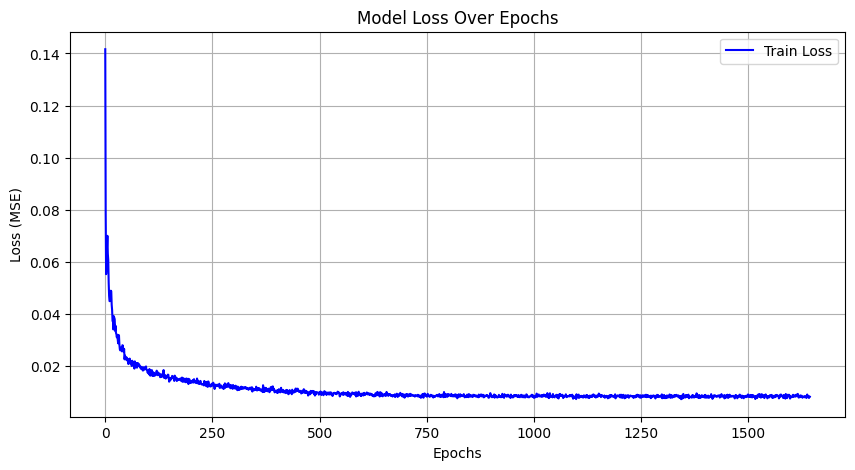

In [84]:
def plot_loss(train_losses, val_losses=None):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss', color='blue')
    if val_losses is not None and len(val_losses) > 0:   # 빈 리스트도 안전 처리
        plt.plot(val_losses, label='Validation Loss', color='red')
    plt.title('Model Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()

# 사용 예시 — train_model이 (model, loss_history) 반환
model = ConcreteANN(input_dim, [20, 20], 'sigmoid')
model, loss_history = train_model(model, X_train, y_train, epochs=5000, lr=0.01)
plot_loss(loss_history)          # ← history['train_loss'] 대신 loss_history


# 실제 예측 스케터 플로우

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

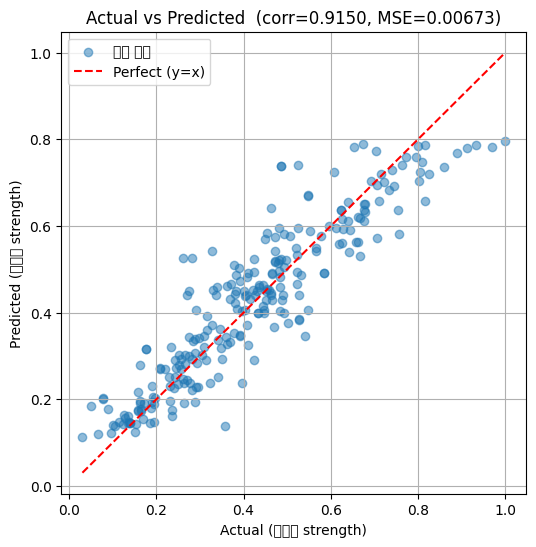

In [85]:
# 테스트 예측값·실제값
pred_np, corr, mse = evaluate_model(model, X_test, y_test)
actual = y_test.cpu().numpy().reshape(-1)

plt.figure(figsize=(6, 6))
plt.scatter(actual, pred_np, alpha=0.5, label='예측 결과')

# 완벽예측선 y=x (점이 이 선에 붙을수록 정확)
lo, hi = actual.min(), actual.max()
plt.plot([lo, hi], [lo, hi], 'r--', label='Perfect (y=x)')

plt.xlabel('Actual (정규화 strength)')
plt.ylabel('Predicted (정규화 strength)')
plt.title(f'Actual vs Predicted  (corr={corr:.4f}, MSE={mse:.5f})')
plt.legend()
plt.grid(True)
plt.show()
